# Decision Tree Classification from Scratch

## Objectives
- Understand how a Decision Tree performs classification.
- Implement a Decision Tree using NumPy.
- Use Gini Impurity to find the best split.
- Evaluate the classifier using standard metrics.
- Compare the implementation with Scikit-Learn.

## Decision Tree Intuition

A Decision Tree recursively splits the dataset into smaller groups.

At each node, the algorithm searches for the feature and threshold that
produce the purest child nodes.

This implementation uses **Gini Impurity**:

Gini = 1 - Σ pᵢ²

where pᵢ is the proportion of samples belonging to class i.

Lower Gini impurity means that a node contains samples mostly belonging
to the same class.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
X, y = make_classification(
    n_samples=400,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_classes=2,
    class_sep=1.4,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2", "Feature_3", "Feature_4"]
)

df["Target"] = y

df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Target
0,0.610393,-0.291811,1.217600,1.332378,1
1,-1.606226,1.726964,-0.852934,-1.982483,0
2,2.902140,1.148637,0.648658,2.149640,1
3,0.412789,1.213098,0.277923,-0.565811,0
4,-0.787645,-0.609783,-2.673406,-0.860891,0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 320
Testing samples: 80


## Decision Tree Implementation

The tree will recursively:

1. Find the best feature and threshold.
2. Split the dataset into left and right branches.
3. Continue splitting until a stopping condition is reached.
4. Store the majority class in leaf nodes.

To control complexity, we will use a maximum tree depth.

In [4]:
class Node:
    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        value=None
    ):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        return self.value is not None

In [5]:
class DecisionTreeScratch:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.root = self._grow_tree(X, y)
        return self

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        if (
            depth >= self.max_depth
            or n_classes == 1
            or n_samples < self.min_samples_split
        ):
            return Node(value=self._most_common_label(y))

        best_feature, best_threshold = self._best_split(X, y)

        if best_feature is None:
            return Node(value=self._most_common_label(y))

        left_indices = X[:, best_feature] <= best_threshold
        right_indices = X[:, best_feature] > best_threshold

        left = self._grow_tree(
            X[left_indices],
            y[left_indices],
            depth + 1
        )

        right = self._grow_tree(
            X[right_indices],
            y[right_indices],
            depth + 1
        )

        return Node(
            feature=best_feature,
            threshold=best_threshold,
            left=left,
            right=right
        )

    def _best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None

        n_features = X.shape[1]

        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])

            for threshold in thresholds:
                gain = self._information_gain(
                    y,
                    X[:, feature],
                    threshold
                )

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _information_gain(self, y, feature_column, threshold):
        parent_gini = self._gini(y)

        left_indices = feature_column <= threshold
        right_indices = feature_column > threshold

        if np.sum(left_indices) == 0 or np.sum(right_indices) == 0:
            return 0

        n = len(y)
        n_left = np.sum(left_indices)
        n_right = np.sum(right_indices)

        child_gini = (
            (n_left / n) * self._gini(y[left_indices])
            + (n_right / n) * self._gini(y[right_indices])
        )

        return parent_gini - child_gini

    def _gini(self, y):
        if len(y) == 0:
            return 0

        counts = np.bincount(y)
        probabilities = counts / len(y)

        return 1 - np.sum(probabilities ** 2)

    def _most_common_label(self, y):
        return Counter(y).most_common(1)[0][0]

    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)

        return self._traverse_tree(x, node.right)

    def predict(self, X):
        return np.array([
            self._traverse_tree(x, self.root)
            for x in np.asarray(X)
        ])

In [6]:
tree = DecisionTreeScratch(
    max_depth=5,
    min_samples_split=2
)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

print("First 10 predictions:", y_pred[:10])
print("Actual values:", y_test[:10])

First 10 predictions: [1 1 1 0 0 0 0 0 0 1]
Actual values: [0 1 1 0 0 0 0 0 0 1]


In [7]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)
    ]
})

results

,Metric,Score
0,Accuracy,0.887500
1,Precision,0.816327
2,Recall,1.000000
3,F1-Score,0.898876


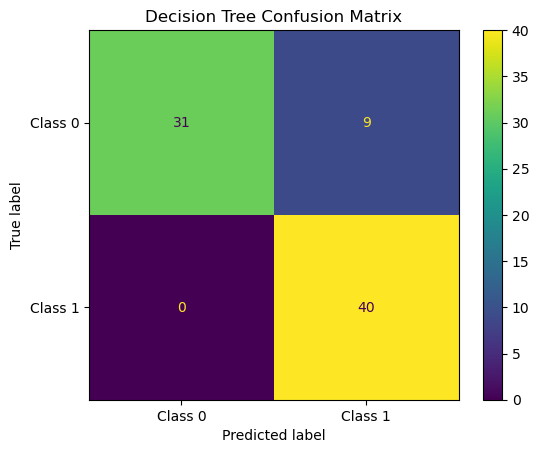

In [8]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

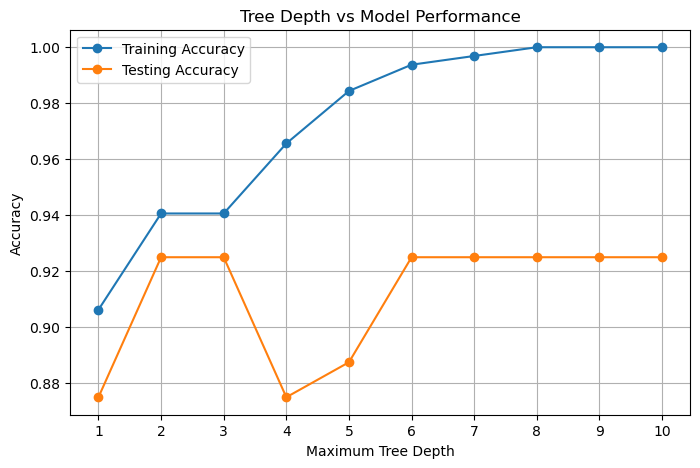

In [9]:
depths = range(1, 11)

train_scores = []
test_scores = []

for depth in depths:
    model = DecisionTreeScratch(max_depth=depth)

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_scores.append(
        accuracy_score(y_train, train_pred)
    )

    test_scores.append(
        accuracy_score(y_test, test_pred)
    )

plt.figure(figsize=(8, 5))

plt.plot(
    depths,
    train_scores,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depths,
    test_scores,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Tree Depth vs Model Performance")
plt.xticks(list(depths))
plt.legend()
plt.grid(True)

plt.show()

In [10]:
sklearn_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

sklearn_tree.fit(X_train, y_train)

sklearn_pred = sklearn_tree.predict(X_test)

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "From Scratch": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)
    ],
    "Scikit-Learn": [
        accuracy_score(y_test, sklearn_pred),
        precision_score(y_test, sklearn_pred, zero_division=0),
        recall_score(y_test, sklearn_pred, zero_division=0),
        f1_score(y_test, sklearn_pred, zero_division=0)
    ]
})

comparison

,Metric,From Scratch,Scikit-Learn
0,Accuracy,0.887500,0.937500
1,Precision,0.816327,0.906977
2,Recall,1.000000,0.975000
3,F1-Score,0.898876,0.939759


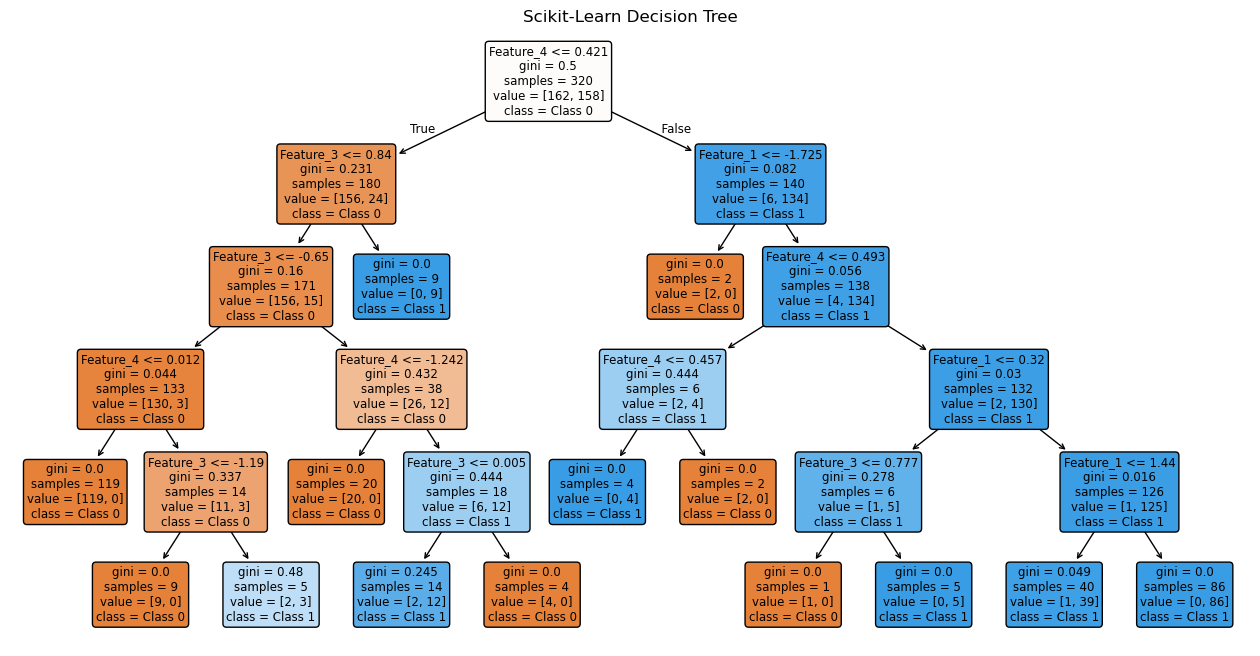

In [11]:
plt.figure(figsize=(16, 8))

plot_tree(
    sklearn_tree,
    feature_names=[
        "Feature_1",
        "Feature_2",
        "Feature_3",
        "Feature_4"
    ],
    class_names=["Class 0", "Class 1"],
    filled=True,
    rounded=True
)

plt.title("Scikit-Learn Decision Tree")
plt.show()